# HW12 — Time Series Forecasting

Домашняя работа: корректный temporal split, baseline-модели, lag/rolling/calendar features и прогнозирование с GRU.

In [1]:
import os
import json
import math
import copy
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 42
DATA_PATH = "S12-hw-dataset.csv"  
ARTIFACTS_DIR = "artifacts"
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, "figures")

os.makedirs(ARTIFACTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Seed:", SEED)

Device: cpu
Seed: 42


In [2]:
def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape_score(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.clip(np.abs(y_true), eps, None)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

def smape_score(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.clip(np.abs(y_true) + np.abs(y_pred), eps, None)
    return np.mean(2.0 * np.abs(y_pred - y_true) / denom) * 100

def regression_metrics(y_true, y_pred):
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(rmse_score(y_true, y_pred)),
        "mape": float(mape_score(y_true, y_pred)),
        "smape": float(smape_score(y_true, y_pred)),
    }

def print_metrics(name, metrics_dict):
    print(
        f"{name}: "
        f"MAE={metrics_dict['mae']:.4f}, "
        f"RMSE={metrics_dict['rmse']:.4f}, "
        f"MAPE={metrics_dict['mape']:.4f}, "
        f"sMAPE={metrics_dict['smape']:.4f}"
    )

def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def ensure_runs_csv(path):
    if not os.path.exists(path):
        cols = [
            "experiment_id",
            "task",
            "dataset",
            "seed",
            "split_summary",
            "window_size",
            "horizon",
            "model_summary",
            "features_summary",
            "scaler",
            "optimizer",
            "lr",
            "epochs_trained",
            "best_val_mae",
            "best_val_rmse",
            "best_val_mape",
            "test_mae",
            "test_rmse",
            "test_mape",
            "notes",
        ]
        pd.DataFrame(columns=cols).to_csv(path, index=False)

def append_run(path, row_dict):
    ensure_runs_csv(path)
    runs_df = pd.read_csv(path)
    runs_df = pd.concat([runs_df, pd.DataFrame([row_dict])], ignore_index=True)
    runs_df.to_csv(path, index=False)

RUNS_CSV_PATH = os.path.join(ARTIFACTS_DIR, "runs.csv")
ensure_runs_csv(RUNS_CSV_PATH)

In [3]:
df = pd.read_csv(DATA_PATH)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["date"].min(), "->", df["date"].max())
print("\nMissing values:")
display(df.isna().sum())

display(df.head())
display(df.tail())

Shape: (4320, 2)
Date range: 2025-01-01 00:00:00 -> 2025-06-29 23:00:00

Missing values:


date      0
target    0
dtype: int64

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


,date,target
4315,2025-06-29 19:00:00,153.05
4316,2025-06-29 20:00:00,134.23
4317,2025-06-29 21:00:00,137.68
4318,2025-06-29 22:00:00,126.53
4319,2025-06-29 23:00:00,120.89


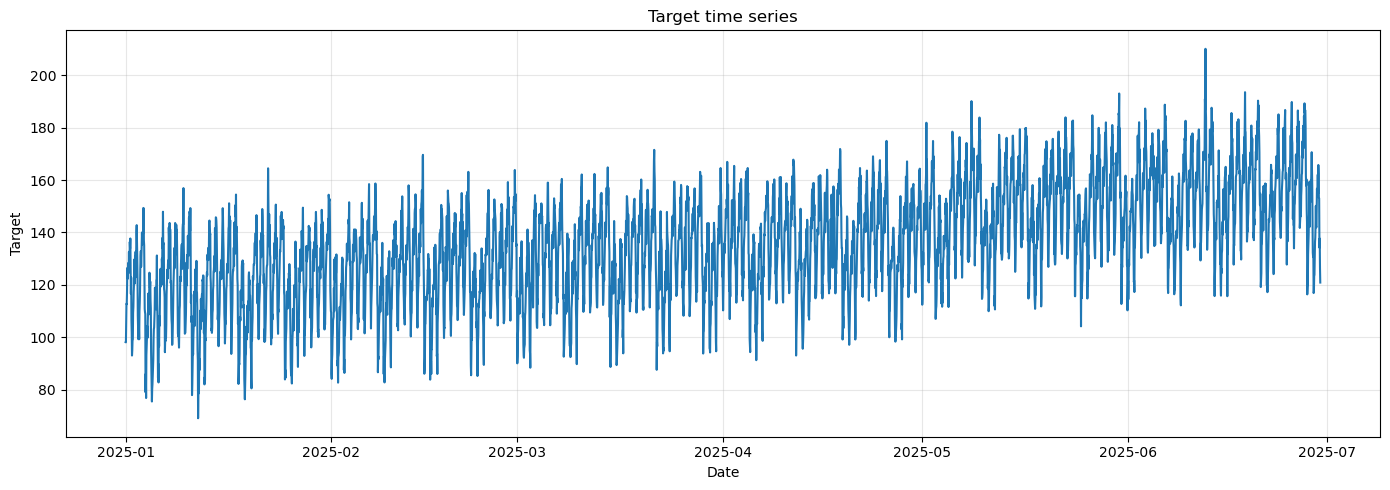

In [15]:
plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["target"])
plt.title("Target time series")
plt.xlabel("Date")
plt.ylabel("Target")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
print("Number of observations:", len(df))
print("Min date:", df["date"].min())
print("Max date:", df["date"].max())
print("Target describe:")
display(df["target"].describe())

Number of observations: 4320
Min date: 2025-01-01 00:00:00
Max date: 2025-06-29 23:00:00
Target describe:


count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64

In [17]:
# 70 / 15 / 15
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Train:", train_df.shape, train_df["date"].min(), "->", train_df["date"].max())
print("Val:  ", val_df.shape, val_df["date"].min(), "->", val_df["date"].max())
print("Test: ", test_df.shape, test_df["date"].min(), "->", test_df["date"].max())

split_summary = (
    f"train=[{train_df['date'].min()}..{train_df['date'].max()}], "
    f"val=[{val_df['date'].min()}..{val_df['date'].max()}], "
    f"test=[{test_df['date'].min()}..{test_df['date'].max()}]"
)
print(split_summary)

Train: (3024, 2) 2025-01-01 00:00:00 -> 2025-05-06 23:00:00
Val:   (648, 2) 2025-05-07 00:00:00 -> 2025-06-02 23:00:00
Test:  (648, 2) 2025-06-03 00:00:00 -> 2025-06-29 23:00:00
train=[2025-01-01 00:00:00..2025-05-06 23:00:00], val=[2025-05-07 00:00:00..2025-06-02 23:00:00], test=[2025-06-03 00:00:00..2025-06-29 23:00:00]


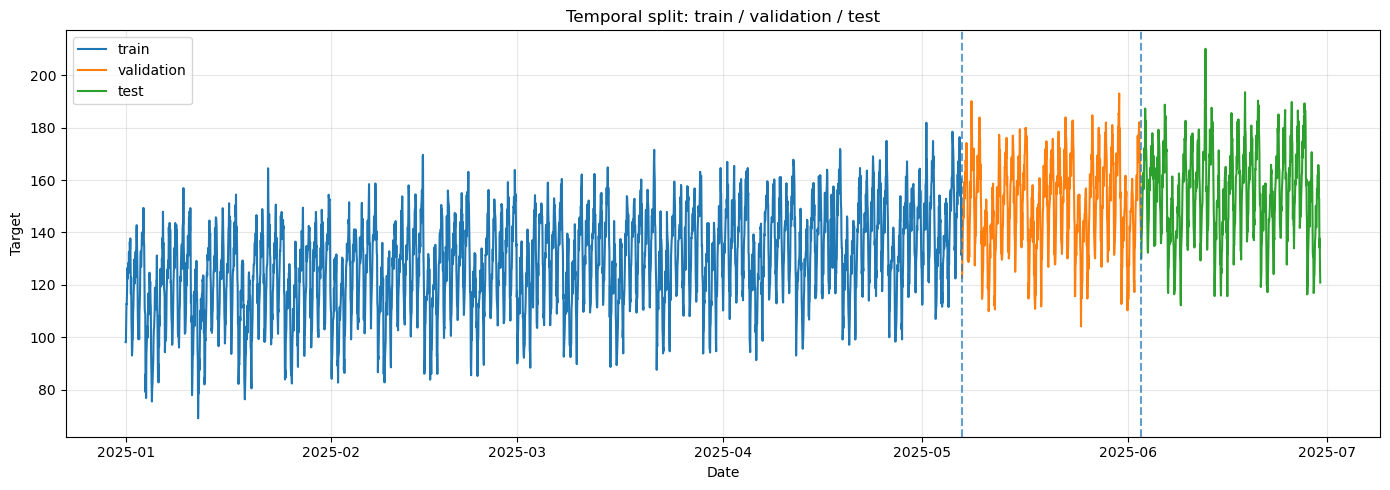

In [18]:
plt.figure(figsize=(14, 5))

plt.plot(train_df["date"], train_df["target"], label="train")
plt.plot(val_df["date"], val_df["target"], label="validation")
plt.plot(test_df["date"], test_df["target"], label="test")

plt.axvline(train_df["date"].max(), linestyle="--", alpha=0.7)
plt.axvline(val_df["date"].max(), linestyle="--", alpha=0.7)

plt.title("Temporal split: train / validation / test")
plt.xlabel("Date")
plt.ylabel("Target")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "series_split.png"), dpi=150, bbox_inches="tight")
plt.show()

**Почему random split некорректен:**  
Во временных рядах модель должна предсказывать будущее по прошлому. При случайном перемешивании часть “будущих” наблюдений может попасть в train, а более ранние — в validation/test. Это даёт утечку информации и нереалистично завышает качество.

In [19]:
def add_time_features(frame: pd.DataFrame) -> pd.DataFrame:
    data = frame.copy()

    # lag features
    data["lag_1"] = data["target"].shift(1)
    data["lag_7"] = data["target"].shift(7)
    data["lag_14"] = data["target"].shift(14)

    # rolling features: только по прошлому, поэтому shift(1)
    data["rolling_mean_7"] = data["target"].shift(1).rolling(window=7).mean()
    data["rolling_std_7"] = data["target"].shift(1).rolling(window=7).std()

    # calendar features
    data["hour"] = data["date"].dt.hour
    data["dayofweek"] = data["date"].dt.dayofweek
    data["day"] = data["date"].dt.day
    data["month"] = data["date"].dt.month
    data["is_weekend"] = (data["dayofweek"] >= 5).astype(int)

    return data

feat_df = add_time_features(df)
display(feat_df.head(20))

,date,target,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,hour,dayofweek,day,month,is_weekend
0,2025-01-01 00:00:00,98.14,NaN,NaN,NaN,NaN,NaN,0,2,1,1,0
1,2025-01-01 01:00:00,98.07,98.14,NaN,NaN,NaN,NaN,1,2,1,1,0
2,2025-01-01 02:00:00,104.70,98.07,NaN,NaN,NaN,NaN,2,2,1,1,0
3,2025-01-01 03:00:00,112.81,104.70,NaN,NaN,NaN,NaN,3,2,1,1,0
4,2025-01-01 04:00:00,112.62,112.81,NaN,NaN,NaN,NaN,4,2,1,1,0
5,2025-01-01 05:00:00,117.29,112.62,NaN,NaN,NaN,NaN,5,2,1,1,0
6,2025-01-01 06:00:00,126.50,117.29,NaN,NaN,NaN,NaN,6,2,1,1,0
7,2025-01-01 07:00:00,126.01,126.50,98.14,NaN,110.018571,10.418147,7,2,1,1,0
8,2025-01-01 08:00:00,122.38,126.01,98.07,NaN,114.000000,10.447405,8,2,1,1,0
9,2025-01-01 09:00:00,128.28,122.38,104.70,NaN,117.472857,8.030400,9,2,1,1,0


### Почему нельзя использовать random split для временных рядов

В задаче прогнозирования временных рядов данные имеют временную зависимость, поэтому важно сохранять порядок наблюдений.

При использовании random split происходит перемешивание данных, из-за чего в обучающую выборку могут попасть значения из будущего относительно validation/test. Это приводит к утечке информации (data leakage) и завышенной оценке качества модели.

Поэтому используется temporal split (разбиение по времени), при котором:
- модель обучается только на прошлом,
- validation и test содержат будущие значения.

Это корректно отражает реальную задачу прогнозирования.

In [20]:
feature_cols = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_std_7",
    "hour",
    "dayofweek",
    "day",
    "month",
    "is_weekend",
]

# после генерации признаков появятся NaN из-за лагов/rolling
feat_df_model = feat_df.dropna().reset_index(drop=True)

n_feat = len(feat_df_model)
train_end_feat = int(n_feat * 0.70)
val_end_feat = int(n_feat * 0.85)

train_feat_df = feat_df_model.iloc[:train_end_feat].copy()
val_feat_df = feat_df_model.iloc[train_end_feat:val_end_feat].copy()
test_feat_df = feat_df_model.iloc[val_end_feat:].copy()

X_train = train_feat_df[feature_cols].copy()
y_train = train_feat_df["target"].copy()

X_val = val_feat_df[feature_cols].copy()
y_val = val_feat_df["target"].copy()

X_test = test_feat_df[feature_cols].copy()
y_test = test_feat_df["target"].copy()

print(X_train.shape, X_val.shape, X_test.shape)

(3014, 10) (646, 10) (646, 10)


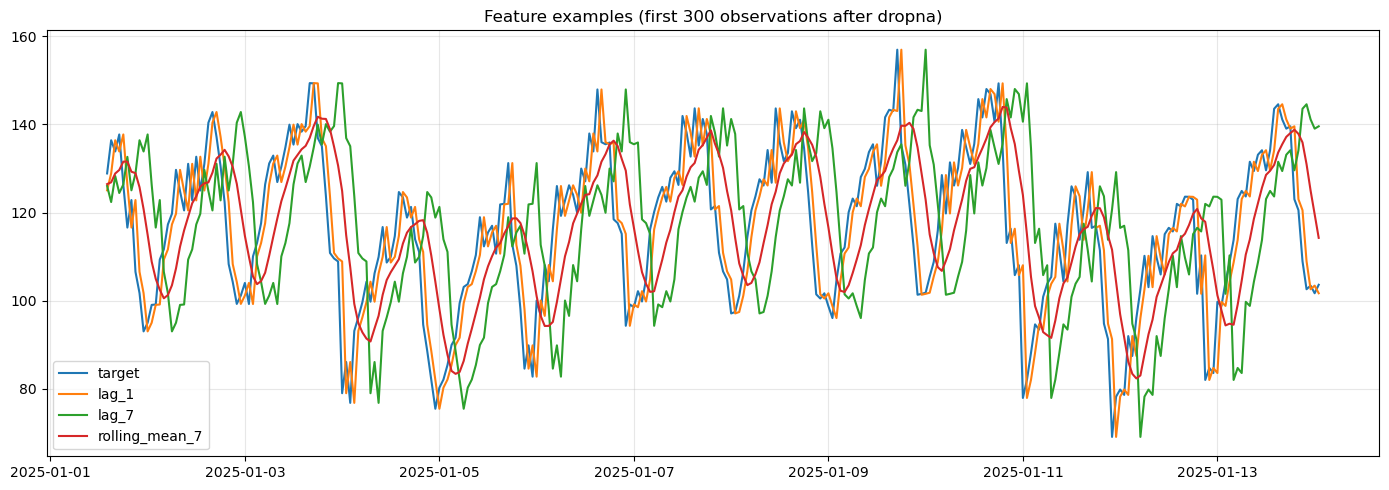

In [21]:
plt.figure(figsize=(14, 5))
example_cols = ["target", "lag_1", "lag_7", "rolling_mean_7"]
for col in example_cols:
    plt.plot(feat_df_model["date"].iloc[:300], feat_df_model[col].iloc[:300], label=col)
plt.title("Feature examples (first 300 observations after dropna)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "feature_examples.png"), dpi=150, bbox_inches="tight")
plt.show()

In [22]:
# B1: прогноз = последнее известное значение
val_naive_pred = val_df["target"].shift(1)
test_naive_pred = test_df["target"].shift(1)

# у первого объекта в каждом куске shift даёт NaN;
# для корректного one-step temporal baseline удобно брать предыдущее наблюдение из общего ряда:
val_naive_pred = df["target"].shift(1).iloc[train_end:val_end].values
test_naive_pred = df["target"].shift(1).iloc[val_end:].values

val_naive_true = df["target"].iloc[train_end:val_end].values
test_naive_true = df["target"].iloc[val_end:].values

b1_val_metrics = regression_metrics(val_naive_true, val_naive_pred)
b1_test_metrics = regression_metrics(test_naive_true, test_naive_pred)

print_metrics("B1 validation", b1_val_metrics)
print_metrics("B1 test", b1_test_metrics)

B1 validation: MAE=6.4448, RMSE=8.2010, MAPE=4.3979, sMAPE=4.3639
B1 test: MAE=6.3424, RMSE=8.0591, MAPE=4.1485, sMAPE=4.1232


In [23]:
append_run(
    RUNS_CSV_PATH,
    {
        "experiment_id": "B1",
        "task": "forecasting",
        "dataset": os.path.basename(DATA_PATH),
        "seed": SEED,
        "split_summary": split_summary,
        "window_size": np.nan,
        "horizon": 1,
        "model_summary": "naive-last",
        "features_summary": "last known value",
        "scaler": "",
        "optimizer": "",
        "lr": np.nan,
        "epochs_trained": 0,
        "best_val_mae": b1_val_metrics["mae"],
        "best_val_rmse": b1_val_metrics["rmse"],
        "best_val_mape": b1_val_metrics["mape"],
        "test_mae": np.nan,
        "test_rmse": np.nan,
        "test_mape": np.nan,
        "notes": "test metrics calculated separately, but final selection should be by validation only",
    },
)

In [24]:
MA_WINDOW = 24  # для почасового ряда разумно начать с 24 часов

moving_avg = df["target"].shift(1).rolling(MA_WINDOW).mean()

val_ma_pred = moving_avg.iloc[train_end:val_end].values
test_ma_pred = moving_avg.iloc[val_end:].values

val_ma_true = df["target"].iloc[train_end:val_end].values
test_ma_true = df["target"].iloc[val_end:].values

# подстраховка на случай NaN
val_mask = ~np.isnan(val_ma_pred)
test_mask = ~np.isnan(test_ma_pred)

b2_val_metrics = regression_metrics(val_ma_true[val_mask], val_ma_pred[val_mask])
b2_test_metrics = regression_metrics(test_ma_true[test_mask], test_ma_pred[test_mask])

print_metrics("B2 validation", b2_val_metrics)
print_metrics("B2 test", b2_test_metrics)

B2 validation: MAE=13.3980, RMSE=16.1699, MAPE=9.1988, sMAPE=8.9950
B2 test: MAE=13.1405, RMSE=16.1108, MAPE=8.7387, sMAPE=8.5342


In [25]:
append_run(
    RUNS_CSV_PATH,
    {
        "experiment_id": "B2",
        "task": "forecasting",
        "dataset": os.path.basename(DATA_PATH),
        "seed": SEED,
        "split_summary": split_summary,
        "window_size": MA_WINDOW,
        "horizon": 1,
        "model_summary": "moving-average",
        "features_summary": f"rolling mean with window={MA_WINDOW}",
        "scaler": "",
        "optimizer": "",
        "lr": np.nan,
        "epochs_trained": 0,
        "best_val_mae": b2_val_metrics["mae"],
        "best_val_rmse": b2_val_metrics["rmse"],
        "best_val_mape": b2_val_metrics["mape"],
        "test_mae": np.nan,
        "test_rmse": np.nan,
        "test_mape": np.nan,
        "notes": f"moving average over previous {MA_WINDOW} steps",
    },
)

In [26]:
feature_scaler = StandardScaler()
feature_scaler.fit(X_train)

X_train_scaled = feature_scaler.transform(X_train)
X_val_scaled = feature_scaler.transform(X_val)
X_test_scaled = feature_scaler.transform(X_test)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

val_ridge_pred = ridge_model.predict(X_val_scaled)
test_ridge_pred = ridge_model.predict(X_test_scaled)

b3_val_metrics = regression_metrics(y_val, val_ridge_pred)
b3_test_metrics = regression_metrics(y_test, test_ridge_pred)

print_metrics("B3 validation", b3_val_metrics)
print_metrics("B3 test", b3_test_metrics)

B3 validation: MAE=6.3327, RMSE=7.8133, MAPE=4.2318, sMAPE=4.3158
B3 test: MAE=5.9478, RMSE=7.5535, MAPE=3.8198, sMAPE=3.8976


In [27]:
append_run(
    RUNS_CSV_PATH,
    {
        "experiment_id": "B3",
        "task": "forecasting",
        "dataset": os.path.basename(DATA_PATH),
        "seed": SEED,
        "split_summary": split_summary,
        "window_size": np.nan,
        "horizon": 1,
        "model_summary": "Ridge(alpha=1.0)",
        "features_summary": ", ".join(feature_cols),
        "scaler": "StandardScaler(features only, fit on train)",
        "optimizer": "",
        "lr": np.nan,
        "epochs_trained": 0,
        "best_val_mae": b3_val_metrics["mae"],
        "best_val_rmse": b3_val_metrics["rmse"],
        "best_val_mape": b3_val_metrics["mape"],
        "test_mae": np.nan,
        "test_rmse": np.nan,
        "test_mape": np.nan,
        "notes": "lag + rolling + calendar features, no leakage from future",
    },
)

In [28]:
WINDOW_SIZE = 24
HORIZON = 1
BATCH_SIZE = 64

target_values = df["target"].values.astype(np.float32)

# scaler только по train
train_target_values = target_values[:train_end]
target_mean = train_target_values.mean()
target_std = train_target_values.std()

scaled_target = (target_values - target_mean) / (target_std + 1e-8)

print("target_mean:", target_mean)
print("target_std:", target_std)

target_mean: 128.20576
target_std: 18.481543


In [ ]:
class SequenceDataset(Dataset):
    def __init__(self, series, start_idx, end_idx, window_size, horizon=1):
        self.X = []
        self.y = []
        self.target_timestamps = []

        # t — индекс прогнозируемой точки
        for t in range(start_idx + window_size, end_idx - horizon + 1):
            x_seq = series[t - window_size:t]
            y_val = series[t + horizon - 1]

            self.X.append(x_seq)
            self.y.append(y_val)
            self.target_timestamps.append(t + horizon - 1)

        self.X = np.array(self.X, dtype=np.float32)
        self.y = np.array(self.y, dtype=np.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx][:, None]   # (window, 1)
        y = self.y[idx]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

train_seq_ds = SequenceDataset(
    scaled_target,
    start_idx=0,
    end_idx=train_end,
    window_size=WINDOW_SIZE,
    horizon=HORIZON,
)

val_seq_ds = SequenceDataset(
    scaled_target,
    start_idx=train_end - WINDOW_SIZE,
    end_idx=val_end,
    window_size=WINDOW_SIZE,
    horizon=HORIZON,
)

test_seq_ds = SequenceDataset(
    scaled_target,
    start_idx=val_end - WINDOW_SIZE,
    end_idx=len(scaled_target),
    window_size=WINDOW_SIZE,
    horizon=HORIZON,
)

print("Train seq:", len(train_seq_ds))
print("Val seq:", len(val_seq_ds))
print("Test seq:", len(test_seq_ds))    

Train seq: 3000
Val seq: 648
Test seq: 648


In [30]:
train_loader = DataLoader(train_seq_ds, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_seq_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_seq_ds, batch_size=BATCH_SIZE, shuffle=False)

In [31]:
class GRURegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, dropout=0.0):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        output, _ = self.gru(x)              # (batch, seq_len, hidden)
        last_hidden = output[:, -1, :]       # (batch, hidden)
        pred = self.head(last_hidden)        # (batch, 1)
        return pred.squeeze(-1)

In [32]:
def inverse_transform_target(x_scaled, mean, std):
    return x_scaled * (std + 1e-8) + mean

def evaluate_model(model, loader, loss_fn, target_mean, target_std, device):
    model.eval()

    losses = []
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            preds = model(xb)
            loss = loss_fn(preds, yb)
            losses.append(loss.item())

            preds_np = preds.detach().cpu().numpy()
            yb_np = yb.detach().cpu().numpy()

            preds_np = inverse_transform_target(preds_np, target_mean, target_std)
            yb_np = inverse_transform_target(yb_np, target_mean, target_std)

            all_preds.append(preds_np)
            all_targets.append(yb_np)

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    metrics = regression_metrics(all_targets, all_preds)
    metrics["loss"] = float(np.mean(losses))
    return metrics, all_targets, all_preds

def train_gru_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    loss_fn,
    epochs,
    target_mean,
    target_std,
    device,
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_mae": [],
        "val_rmse": [],
        "val_mape": [],
    }

    best_state = None
    best_val_mae = float("inf")
    best_val_metrics = None
    best_epoch = -1

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            preds = model(xb)
            loss = loss_fn(preds, yb)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_metrics, _, _ = evaluate_model(
            model=model,
            loader=val_loader,
            loss_fn=loss_fn,
            target_mean=target_mean,
            target_std=target_std,
            device=device,
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_mae"].append(val_metrics["mae"])
        history["val_rmse"].append(val_metrics["rmse"])
        history["val_mape"].append(val_metrics["mape"])

        if val_metrics["mae"] < best_val_mae:
            best_val_mae = val_metrics["mae"]
            best_val_metrics = val_metrics
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

        if epoch % 5 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:03d}/{epochs} | "
                f"train_loss={train_loss:.6f} | "
                f"val_loss={val_metrics['loss']:.6f} | "
                f"val_mae={val_metrics['mae']:.4f} | "
                f"val_rmse={val_metrics['rmse']:.4f}"
            )

    return {
        "history": history,
        "best_state": best_state,
        "best_epoch": best_epoch,
        "best_val_metrics": best_val_metrics,
    }

In [33]:
GRU_CONFIG = {
    "input_size": 1,
    "hidden_size": 32,
    "num_layers": 1,
    "dropout": 0.0,
    "window_size": WINDOW_SIZE,
    "horizon": HORIZON,
    "batch_size": BATCH_SIZE,
    "lr": 1e-3,
    "epochs": 20,
    "optimizer": "Adam",
    "loss": "MSELoss",
    "scaler": "standardize target on train only",
    "seed": SEED,
    "device": str(device),
}

gru_model = GRURegressor(
    input_size=GRU_CONFIG["input_size"],
    hidden_size=GRU_CONFIG["hidden_size"],
    num_layers=GRU_CONFIG["num_layers"],
    dropout=GRU_CONFIG["dropout"],
).to(device)

optimizer = torch.optim.Adam(gru_model.parameters(), lr=GRU_CONFIG["lr"])
loss_fn = nn.MSELoss()

gru_result = train_gru_model(
    model=gru_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=GRU_CONFIG["epochs"],
    target_mean=target_mean,
    target_std=target_std,
    device=device,
)

print("Best epoch:", gru_result["best_epoch"])
print_metrics("R1 best validation", gru_result["best_val_metrics"])

Epoch 001/20 | train_loss=0.757080 | val_loss=1.107545 | val_mae=16.5461 | val_rmse=19.4297
Epoch 005/20 | train_loss=0.164362 | val_loss=0.172866 | val_mae=6.2296 | val_rmse=7.7992
Epoch 010/20 | train_loss=0.148762 | val_loss=0.164035 | val_mae=6.0607 | val_rmse=7.6058
Epoch 015/20 | train_loss=0.142514 | val_loss=0.164344 | val_mae=6.0818 | val_rmse=7.6171
Epoch 020/20 | train_loss=0.108847 | val_loss=0.170974 | val_mae=5.9482 | val_rmse=7.6512
Best epoch: 20
R1 best validation: MAE=5.9482, RMSE=7.6512, MAPE=3.9636, sMAPE=4.0213


In [34]:
best_gru_path = os.path.join(ARTIFACTS_DIR, "best_gru.pt")
best_gru_config_path = os.path.join(ARTIFACTS_DIR, "best_gru_config.json")

torch.save(gru_result["best_state"], best_gru_path)

best_gru_config = {
    **GRU_CONFIG,
    "target_mean": float(target_mean),
    "target_std": float(target_std),
    "best_epoch": int(gru_result["best_epoch"]),
    "best_val_metrics": gru_result["best_val_metrics"],
}

save_json(best_gru_config, best_gru_config_path)

print("Saved:", best_gru_path)
print("Saved:", best_gru_config_path)

Saved: artifacts\best_gru.pt
Saved: artifacts\best_gru_config.json


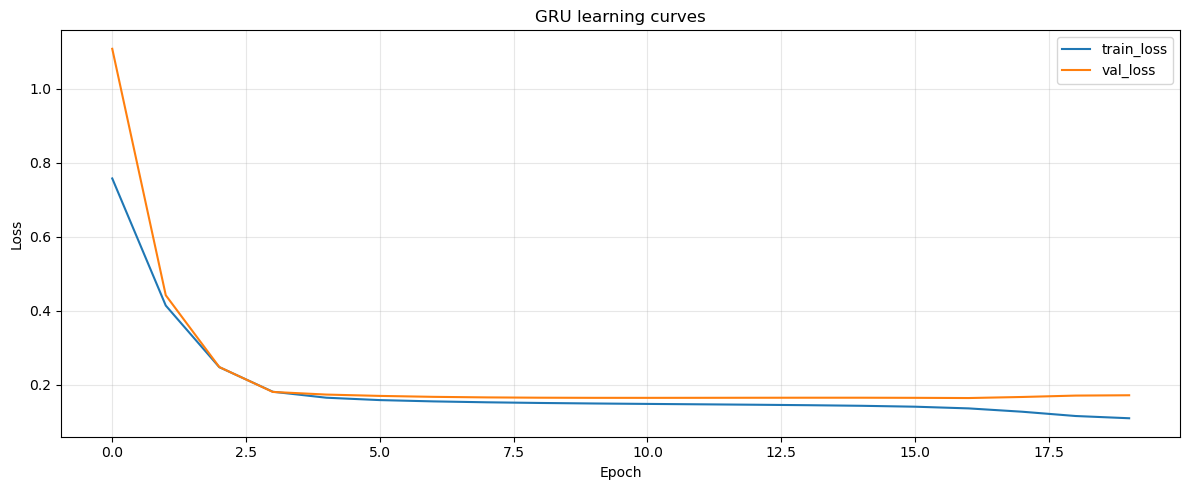

In [35]:
history = gru_result["history"]

plt.figure(figsize=(12, 5))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.title("GRU learning curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "gru_learning_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

In [36]:
best_gru = GRURegressor(
    input_size=GRU_CONFIG["input_size"],
    hidden_size=GRU_CONFIG["hidden_size"],
    num_layers=GRU_CONFIG["num_layers"],
    dropout=GRU_CONFIG["dropout"],
).to(device)

best_gru.load_state_dict(gru_result["best_state"])

r1_val_metrics, val_targets_gru, val_preds_gru = evaluate_model(
    model=best_gru,
    loader=val_loader,
    loss_fn=loss_fn,
    target_mean=target_mean,
    target_std=target_std,
    device=device,
)

r1_test_metrics, test_targets_gru, test_preds_gru = evaluate_model(
    model=best_gru,
    loader=test_loader,
    loss_fn=loss_fn,
    target_mean=target_mean,
    target_std=target_std,
    device=device,
)

print_metrics("R1 validation", r1_val_metrics)
print_metrics("R1 test", r1_test_metrics)

R1 validation: MAE=5.9482, RMSE=7.6512, MAPE=3.9636, sMAPE=4.0213
R1 test: MAE=7.0313, RMSE=9.0676, MAPE=4.4513, sMAPE=4.5629


In [37]:
append_run(
    RUNS_CSV_PATH,
    {
        "experiment_id": "R1",
        "task": "forecasting",
        "dataset": os.path.basename(DATA_PATH),
        "seed": SEED,
        "split_summary": split_summary,
        "window_size": WINDOW_SIZE,
        "horizon": HORIZON,
        "model_summary": (
            f"GRU(input_size={GRU_CONFIG['input_size']}, "
            f"hidden_size={GRU_CONFIG['hidden_size']}, "
            f"num_layers={GRU_CONFIG['num_layers']}, "
            f"dropout={GRU_CONFIG['dropout']})"
        ),
        "features_summary": f"windowed target sequence of length {WINDOW_SIZE}",
        "scaler": GRU_CONFIG["scaler"],
        "optimizer": GRU_CONFIG["optimizer"],
        "lr": GRU_CONFIG["lr"],
        "epochs_trained": gru_result["best_epoch"],
        "best_val_mae": r1_val_metrics["mae"],
        "best_val_rmse": r1_val_metrics["rmse"],
        "best_val_mape": r1_val_metrics["mape"],
        "test_mae": np.nan,
        "test_rmse": np.nan,
        "test_mape": np.nan,
        "notes": "best model selected by validation MAE",
    },
)

In [38]:
comparison_df = pd.DataFrame(
    [
        {"experiment_id": "B1", "val_mae": b1_val_metrics["mae"], "val_rmse": b1_val_metrics["rmse"], "val_mape": b1_val_metrics["mape"]},
        {"experiment_id": "B2", "val_mae": b2_val_metrics["mae"], "val_rmse": b2_val_metrics["rmse"], "val_mape": b2_val_metrics["mape"]},
        {"experiment_id": "B3", "val_mae": b3_val_metrics["mae"], "val_rmse": b3_val_metrics["rmse"], "val_mape": b3_val_metrics["mape"]},
        {"experiment_id": "R1", "val_mae": r1_val_metrics["mae"], "val_rmse": r1_val_metrics["rmse"], "val_mape": r1_val_metrics["mape"]},
    ]
)

display(comparison_df.sort_values("val_mae"))

,experiment_id,val_mae,val_rmse,val_mape
3,R1,5.948238,7.651246,3.963628
2,B3,6.332655,7.813322,4.231802
0,B1,6.444815,8.201023,4.397922
1,B2,13.397980,16.169904,9.198834


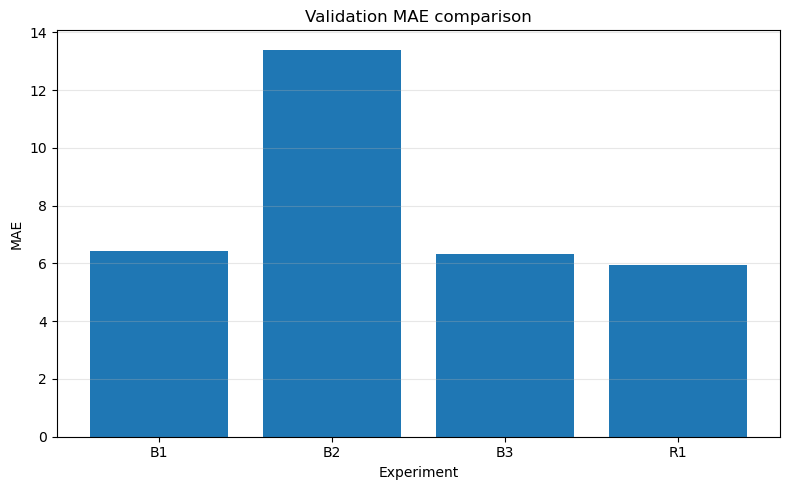

In [39]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["experiment_id"], comparison_df["val_mae"])
plt.title("Validation MAE comparison")
plt.xlabel("Experiment")
plt.ylabel("MAE")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "baselines_compare.png"), dpi=150, bbox_inches="tight")
plt.show()

In [40]:
results_for_selection = {
    "B1": {"model_name": "naive-last", "val_metrics": b1_val_metrics},
    "B2": {"model_name": "moving-average", "val_metrics": b2_val_metrics},
    "B3": {"model_name": "ridge-lag-features", "val_metrics": b3_val_metrics},
    "R1": {"model_name": "gru-forecast", "val_metrics": r1_val_metrics},
}

best_experiment_id = min(results_for_selection, key=lambda k: results_for_selection[k]["val_metrics"]["mae"])
best_model_name = results_for_selection[best_experiment_id]["model_name"]

print("Best experiment by validation MAE:", best_experiment_id, "-", best_model_name)
for exp_id, info in results_for_selection.items():
    print(exp_id, info["model_name"], info["val_metrics"]["mae"])

Best experiment by validation MAE: R1 - gru-forecast
B1 naive-last 6.444814814814815
B2 moving-average 13.397980324074075
B3 ridge-lag-features 6.33265483129719
R1 gru-forecast 5.948238372802734


In [41]:
final_test_metrics = None
final_test_true = None
final_test_pred = None

if best_experiment_id == "B1":
    final_test_true = test_naive_true
    final_test_pred = test_naive_pred
    final_test_metrics = b1_test_metrics

elif best_experiment_id == "B2":
    final_test_true = test_ma_true[test_mask]
    final_test_pred = test_ma_pred[test_mask]
    final_test_metrics = b2_test_metrics

elif best_experiment_id == "B3":
    final_test_true = np.asarray(y_test)
    final_test_pred = np.asarray(test_ridge_pred)
    final_test_metrics = b3_test_metrics

elif best_experiment_id == "R1":
    final_test_true = np.asarray(test_targets_gru)
    final_test_pred = np.asarray(test_preds_gru)
    final_test_metrics = r1_test_metrics

print("Final selected model:", best_experiment_id, "-", best_model_name)
print_metrics("Final TEST", final_test_metrics)

Final selected model: R1 - gru-forecast
Final TEST: MAE=7.0313, RMSE=9.0676, MAPE=4.4513, sMAPE=4.5629


In [42]:
runs_df = pd.read_csv(RUNS_CSV_PATH)

mask = runs_df["experiment_id"] == best_experiment_id
runs_df.loc[mask, "test_mae"] = final_test_metrics["mae"]
runs_df.loc[mask, "test_rmse"] = final_test_metrics["rmse"]
runs_df.loc[mask, "test_mape"] = final_test_metrics["mape"]

runs_df.to_csv(RUNS_CSV_PATH, index=False)
display(runs_df)

,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,train=[2025-01-01 00:00:00..2025-05-06 23:00:0...,NaN,1,naive-last,last known value,NaN,NaN,NaN,0,6.444815,8.201023,4.397922,NaN,NaN,NaN,"test metrics calculated separately, but final ..."
1,B2,forecasting,S12-hw-dataset.csv,42,train=[2025-01-01 00:00:00..2025-05-06 23:00:0...,24.0,1,moving-average,rolling mean with window=24,NaN,NaN,NaN,0,13.397980,16.169904,9.198834,NaN,NaN,NaN,moving average over previous 24 steps
2,B3,forecasting,S12-hw-dataset.csv,42,train=[2025-01-01 00:00:00..2025-05-06 23:00:0...,NaN,1,Ridge(alpha=1.0),"lag_1, lag_7, lag_14, rolling_mean_7, rolling_...","StandardScaler(features only, fit on train)",NaN,NaN,0,6.332655,7.813322,4.231802,NaN,NaN,NaN,"lag + rolling + calendar features, no leakage ..."
3,R1,forecasting,S12-hw-dataset.csv,42,train=[2025-01-01 00:00:00..2025-05-06 23:00:0...,24.0,1,"GRU(input_size=1, hidden_size=32, num_layers=1...",windowed target sequence of length 24,standardize target on train only,Adam,0.001,20,5.948238,7.651246,3.963628,7.031307,9.067556,4.451287,best model selected by validation MAE


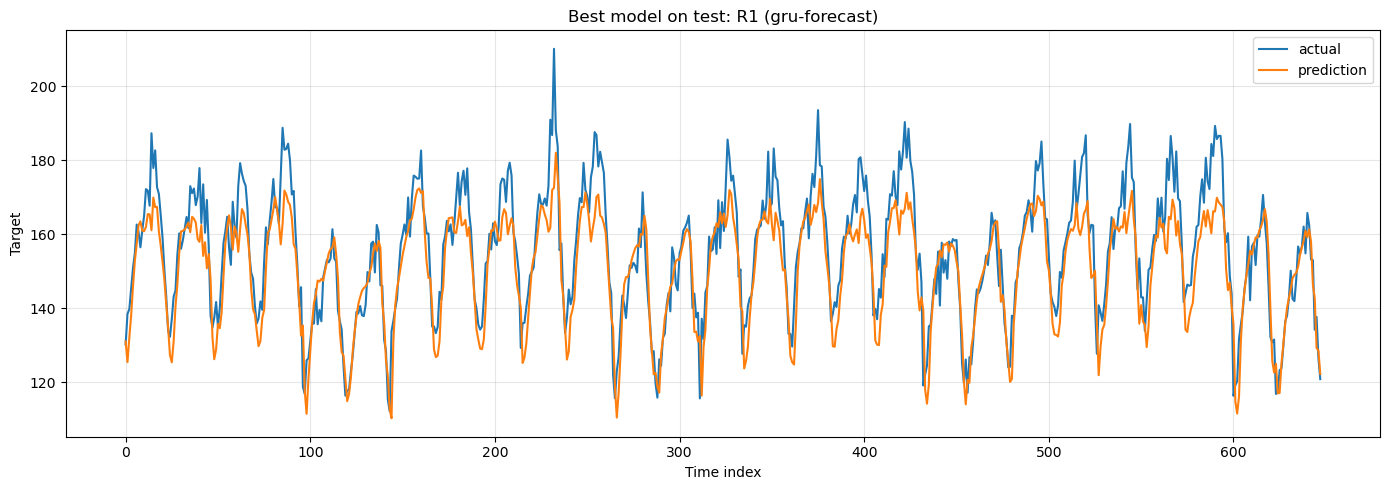

In [43]:
plt.figure(figsize=(14, 5))
plt.plot(final_test_true, label="actual")
plt.plot(final_test_pred, label="prediction")
plt.title(f"Best model on test: {best_experiment_id} ({best_model_name})")
plt.xlabel("Time index")
plt.ylabel("Target")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "best_forecast_test.png"), dpi=150, bbox_inches="tight")
plt.show()

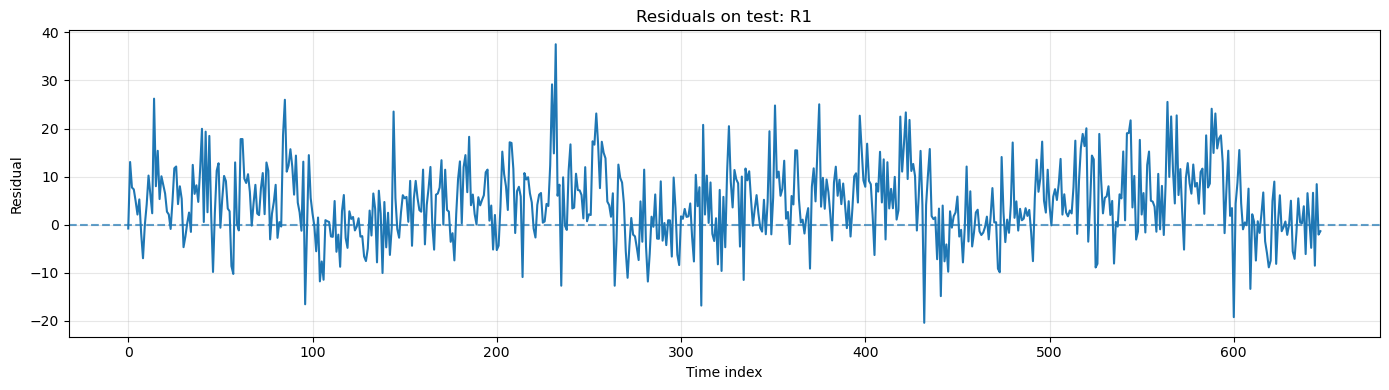

In [44]:
residuals = final_test_true - final_test_pred

plt.figure(figsize=(14, 4))
plt.plot(residuals)
plt.axhline(0, linestyle="--", alpha=0.7)
plt.title(f"Residuals on test: {best_experiment_id}")
plt.xlabel("Time index")
plt.ylabel("Residual")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "residuals_best.png"), dpi=150, bbox_inches="tight")
plt.show()

In [45]:
print("Artifacts dir:", ARTIFACTS_DIR)
print("Figures dir:", FIGURES_DIR)

for root, dirs, files in os.walk(ARTIFACTS_DIR):
    level = root.replace(ARTIFACTS_DIR, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 2 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")

Artifacts dir: artifacts
Figures dir: artifacts\figures
artifacts/
  best_gru.pt
  best_gru_config.json
  runs.csv
  figures/
    baselines_compare.png
    best_forecast_test.png
    feature_examples.png
    gru_learning_curves.png
    residuals_best.png
    series_split.png


## Краткие выводы

- Данные отсортированы по времени, использован корректный temporal split.
- Построены baseline-подходы: naive-last, moving-average, Ridge с lag/rolling/calendar features.
- Для нейросетевого подхода подготовлено оконное представление и обучена GRU.
- Лучшая модель выбрана по validation MAE.
- Test использован один раз для финальной оценки выбранного лучшего подхода.